[{'day': 1, 'hour': 0, 'irradiance': 0, 'temperature': 10.0}, {'day': 1, 'hour': 1, 'irradiance': 0, 'temperature': 10.0}, {'day': 1, 'hour': 2, 'irradiance': 0, 'temperature': 10.0}, {'day': 1, 'hour': 3, 'irradiance': 0, 'temperature': 10.0}, {'day': 1, 'hour': 4, 'irradiance': 0, 'temperature': 10.0}, {'day': 1, 'hour': 5, 'irradiance': 0, 'temperature': 10.0}, {'day': 1, 'hour': 6, 'irradiance': 0, 'temperature': 10.0}, {'day': 1, 'hour': 7, 'irradiance': 207.0552360820166, 'temperature': 14.141104721640332}, {'day': 1, 'hour': 8, 'irradiance': 399.99999999999994, 'temperature': 18.0}, {'day': 1, 'hour': 9, 'irradiance': 565.685424949238, 'temperature': 21.31370849898476}, {'day': 1, 'hour': 10, 'irradiance': 692.8203230275509, 'temperature': 23.856406460551018}, {'day': 1, 'hour': 11, 'irradiance': 772.7406610312546, 'temperature': 25.45481322062509}]


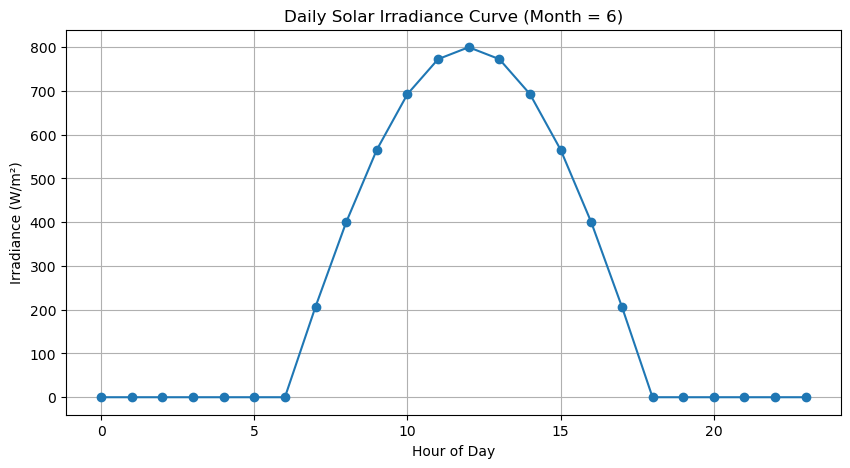

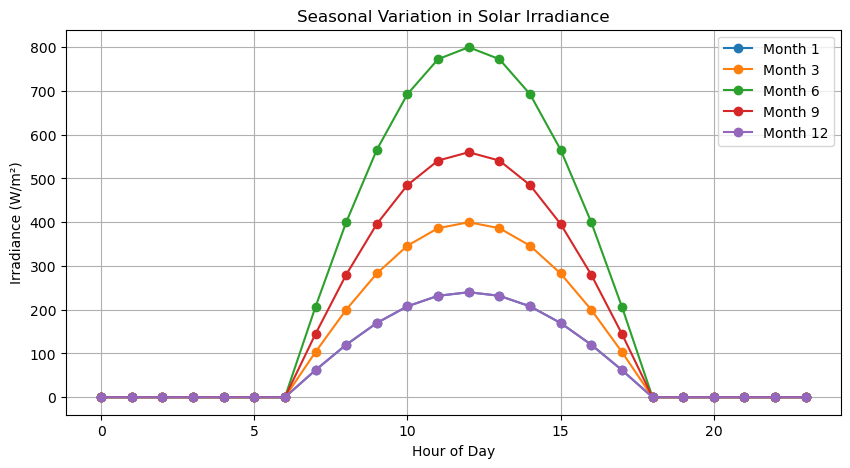

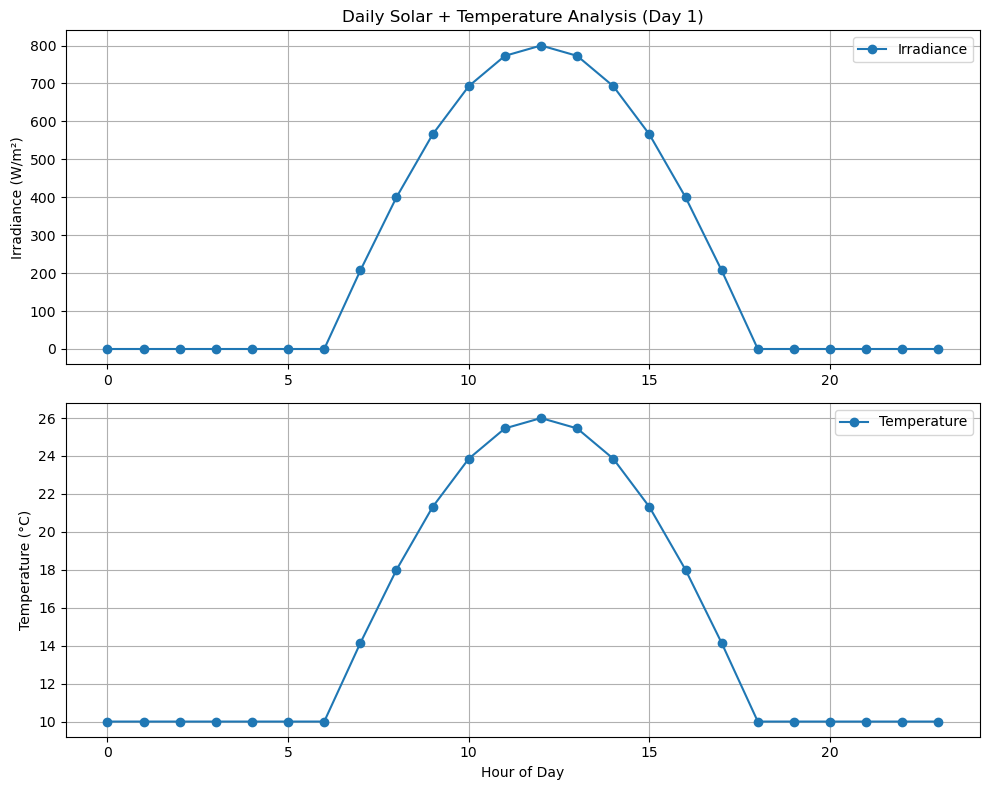

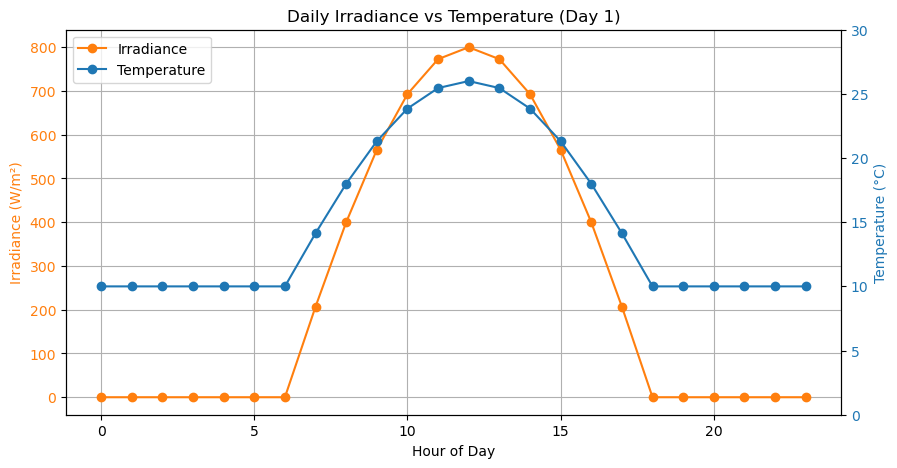

In [14]:
import math
import matplotlib.pyplot as plt

def generate_solar_data(n):
    data = []
    
    for i in range(n):
        pass                      # we'll write this in the next step
    
    return data

{
    "date": "YYYY-MM-DD",         #String
    "hour": int,                 #Integer
    "temperature": float,
    "irradiance": float
}

def seasonal_factor(month):
    if month in [6, 7]:
        return 1.0              # peak summer
    elif month in [4, 5, 8, 9]:
        return 0.7              # spring/autumn
    elif month in [2, 3, 10, 11]:
        return 0.5              # transitional months
    elif month in [12, 1]:
        return 0.3              # winter
    else:
        return 0.5              #Safety fallback
        
def compute_irradiance(hour, month):
    A = 800
    angle = (math.pi / 12) * (hour - 6)
    base = math.sin(angle)

    irradiance = A * base

    return max(0, irradiance * seasonal_factor(month))   #Return whichever is bigger: 0 or value

def compute_temperature(irradiance):
    base_temp = 10  # typical baseline (°C)

    temp = base_temp + (irradiance * 0.02)

    return temp

def generate_dataset(month):
    dataset = []
    
    for day in range(1, 4):
        for hour in range(24):
            record = {}
            record["day"] = day
            record["hour"] = hour
        
            # Irradiance
            irr = compute_irradiance(hour, month)
            record["irradiance"] = irr
            
            # Temperature (NEW)
            record["temperature"] = compute_temperature(irr)
    
            dataset.append(record)
           
    return dataset

def filter_by_value(dataset, key, value):
    result = []
    
    for r in dataset:
        if r[key] == value:
            result.append(r)
    
    return result

month = 6
dataset = generate_dataset(month)

print(dataset[:12])   

day_1 = filter_by_value(dataset, "day", 1)

hours = []
irradiance = []

for r in day_1:
    hours.append(r["hour"])
    irradiance.append(r["irradiance"])

plt.figure(figsize=(10,5))
plt.plot(hours, irradiance, marker="o")

plt.xlabel("Hour of Day")
plt.ylabel("Irradiance (W/m²)")
plt.title("Daily Solar Irradiance Curve (Month = 6)")
plt.grid(True)

plt.show()

months = [1, 3, 6, 9, 12]

plt.figure(figsize=(10,5))

for m in months:
    hours = []
    irradiance = []

    for h in range(24):
        hours.append(h)
        irradiance.append(compute_irradiance(h, m))

   
    plt.plot(hours, irradiance, marker="o", label=f"Month {m}")

plt.xlabel("Hour of Day")
plt.ylabel("Irradiance (W/m²)")
plt.title("Seasonal Variation in Solar Irradiance")
plt.grid(True)
plt.legend()

plt.show()
    
def plot_daily_analysis(dataset, day_value):
    day_data = []

    for r in dataset:
        if r["day"] == day_value:
            day_data.append(r)

    hours = []
    irradiance = []
    temperature = []

    for r in day_data:
        hours.append(r["hour"])
        irradiance.append(r["irradiance"])
        temperature.append(r["temperature"])

    fig, axes = plt.subplots(2, 1, figsize=(10,8))   #Creates two separate plots, based on same dataset analysis

    # ------------------------
    # Top plot: Irradiance                           #Each plot needs its own axis defining
    # ------------------------
    axes[0].plot(hours, irradiance, label="Irradiance", marker="o")
    axes[0].set_title(f"Daily Solar + Temperature Analysis (Day {day_value})")
    axes[0].set_ylabel("Irradiance (W/m²)")
    axes[0].grid(True)
    axes[0].legend()

    # ------------------------
    # Bottom plot: Temperature
    # ------------------------
    axes[1].plot(hours, temperature, label="Temperature", marker="o")
    axes[1].set_xlabel("Hour of Day")
    axes[1].set_ylabel("Temperature (°C)")
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_daily_analysis(dataset, 1)   
   
def plot_daily_twin_axis(dataset, day_value):   #Plts both irradiance and temp on same graph, different y-axes
    # -----------------------------
    # Filter data for selected day
    # -----------------------------
    day_data = []

    for r in dataset:
        if r["day"] == day_value:
            day_data.append(r)

    # -----------------------------
    # Extract lists
    # -----------------------------
    hours = []
    irradiance = []
    temperature = []

    for r in day_data:
        hours.append(r["hour"])
        irradiance.append(r["irradiance"])
        temperature.append(r["temperature"])

    # -----------------------------
    # Create figure + primary axis
    # -----------------------------
    fig, ax1 = plt.subplots(figsize=(10,5))

    # Irradiance (left axis)
    ax1.plot(hours, irradiance, color="tab:orange", marker="o", label="Irradiance")
    ax1.set_xlabel("Hour of Day")
    ax1.set_ylabel("Irradiance (W/m²)", color="tab:orange")
    ax1.tick_params(axis='y', labelcolor="tab:orange")
    ax1.grid(True)

    # -----------------------------
    # Secondary axis (temperature)
    # -----------------------------
    ax2 = ax1.twinx()

    ax2.set_ylim(0, 30)          #Sets different height of second y-axis so plots don't overlap.
    ax2.plot(hours, temperature, color="tab:blue", marker="o", label="Temperature")
    ax2.set_ylabel("Temperature (°C)", color="tab:blue")
    ax2.tick_params(axis='y', labelcolor="tab:blue")

    # -----------------------------
    # Title + layout
    # -----------------------------
    plt.title(f"Daily Irradiance vs Temperature (Day {day_value})")

    # Optional: combined legend handling
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    plt.show()


# -----------------------------
# RUN IT
# -----------------------------
plot_daily_twin_axis(dataset, 1)

In [14]:
print(len(dataset))
print(dataset[:3])

72
[{'day': 1, 'hour': 0, 'irradiance': 0}, {'day': 1, 'hour': 1, 'irradiance': 0}, {'day': 1, 'hour': 2, 'irradiance': 0}]


In [17]:
print(hours[:5])
print(irradiance[:5])

[]
[]


In [ ]:
def filter_by_value(dataset, key, value):
    result = []
    
    for r in dataset:
        if r[key] == value:
            result.append(r)
    
    return result

In [13]:
dataset = generate_dataset(6)

print(dataset[:17])

[{'day': 1, 'hour': 0, 'irradiance': 0, 'temperature': 10.0}, {'day': 1, 'hour': 1, 'irradiance': 0, 'temperature': 10.0}, {'day': 1, 'hour': 2, 'irradiance': 0, 'temperature': 10.0}, {'day': 1, 'hour': 3, 'irradiance': 0, 'temperature': 10.0}, {'day': 1, 'hour': 4, 'irradiance': 0, 'temperature': 10.0}, {'day': 1, 'hour': 5, 'irradiance': 0, 'temperature': 10.0}, {'day': 1, 'hour': 6, 'irradiance': 0, 'temperature': 10.0}, {'day': 1, 'hour': 7, 'irradiance': 207.0552360820166, 'temperature': 14.141104721640332}, {'day': 1, 'hour': 8, 'irradiance': 399.99999999999994, 'temperature': 18.0}, {'day': 1, 'hour': 9, 'irradiance': 565.685424949238, 'temperature': 21.31370849898476}, {'day': 1, 'hour': 10, 'irradiance': 692.8203230275509, 'temperature': 23.856406460551018}, {'day': 1, 'hour': 11, 'irradiance': 772.7406610312546, 'temperature': 25.45481322062509}, {'day': 1, 'hour': 12, 'irradiance': 800.0, 'temperature': 26.0}, {'day': 1, 'hour': 13, 'irradiance': 772.7406610312546, 'temperat